In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ['JAX_PLATFORMS'] = 'cpu'
import yaml
import sys
sys.path.append("..")

import os.path as osp
import torch
import numpy as np
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm_notebook as tqdm
import torch.nn as nn
from torch_model import DiT
from torch_vae import AutoencoderKL

In [3]:
import numpy as np

def show_image_grid(images, cols, figsize=(12,12), save_path=None, cmap=None):
    """
    Draw a grid of images.

    Args:
        images: numpy array or list-like of shape (B, H, W, C) or (B, C, H, W).
                Expected H=W=256 and C=3, but other sizes will work too.
                Values can be uint8 [0..255], float [0..1] or float in [-1,1].
        rows: number of grid rows.
        cols: number of grid columns.
        figsize: tuple passed to plt.figure.
        save_path: optional path to save the figure (PNG/JPG). If None, figure is not saved.
        cmap: optional colormap for single-channel images.

    Returns:
        fig, axes - matplotlib Figure and axes array (flattened).
    """
    # Convert input to numpy array
    imgs = np.asarray(images)

    if imgs.ndim not in (3,4):
        raise ValueError(f"images must be 3D or 4D array, got shape {imgs.shape}")

    # If single image (H,W,C), expand to batch
    if imgs.ndim == 3:
        imgs = imgs[None, ...]

    B = imgs.shape[0]

    if B<cols:
        cols=B
        rows=1
    else:
        rows = B//cols + int(B%cols!=0)
    
    # Normalize to float in [0,1] for plotting
    if imgs.dtype == np.uint8:
        imgs_plot = imgs.astype(np.float32) / 255.0
    else:
        imgs_plot = imgs.astype(np.float32)
        # If values appear in [-1,1], convert to [0,1]
        if imgs_plot.min() < -0.1 and imgs_plot.max() <= 1.1:
            imgs_plot = (imgs_plot * 0.5) + 0.5
        # clip any out-of-range values
        imgs_plot = np.clip(imgs_plot, 0.0, 1.0)

    # Prepare grid: only display up to rows*cols images
    grid_n = rows * cols
    display_n = min(B, grid_n)

    # If fewer images than grid, create black placeholders
    H, W = imgs_plot.shape[1], imgs_plot.shape[2]
    if imgs_plot.shape[3] == 1:
        imgs_plot = imgs_plot[...,0]  # will be handled by imshow single channel

    padded = []
    for i in range(grid_n):
        if i < display_n:
            padded.append(imgs_plot[i])
        else:
            # black image
            if imgs_plot.ndim == 4 and imgs_plot.shape[3] == 3:
                padded.append(np.zeros((H, W, 3), dtype=np.float32))
            else:
                padded.append(np.zeros((H, W), dtype=np.float32))
    padded = np.stack(padded, axis=0)

    # Create figure and axes
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    # axes may be 2D array; flatten for easy indexing
    axes_flat = np.array(axes).reshape(-1)

    for idx, ax in enumerate(axes_flat):
        img = padded[idx]
        ax.axis('off')
        if img.ndim == 3 and img.shape[2] == 3:
            ax.imshow(img, interpolation='nearest')
        else:
            ax.imshow(img, cmap=cmap or 'gray', interpolation='nearest', vmin=0.0, vmax=1.0)

    plt.tight_layout(pad=0.0)
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    return fig, axes_flat

## For FID

In [4]:
from skimage.transform import resize
from utils.fid import get_fid_network, fid_from_stats
get_fid_activations = get_fid_network()
fid_stats = "../results/celebahq256_fid_stats.npz"
truth_fid_stats = np.load(fid_stats)



def calc_fid(all_images):
    resized_images = np.stack([resize(img, (299, 299, 3), anti_aliasing=True) for img in all_images])
    resized_images = np.clip(resized_images, -1, 1)
    acts = get_fid_activations(resized_images)
    if acts.ndim == 4 and acts.shape[1:3] == (1, 1):
        acts = acts[..., 0, 0, :] if acts.shape[-1] == 2048 else acts.squeeze((1,2))
    acts = np.array(acts)
    mu1 = np.mean(acts, axis=0)
    sigma1 = np.cov(acts, rowvar=False)
    
    fid = fid_from_stats(mu1, sigma1, truth_fid_stats['mu'], truth_fid_stats['sigma'])
    return fid


ModuleNotFoundError: jax requires jaxlib to be installed. See https://github.com/google/jax#installation for installation instructions.

In [ ]:
from typing import List, Dict, Tuple

def display_generation_steps(
    step_dicts: List[Dict[Tuple[int, int], np.ndarray]],
    batch_index: int = 0,
    selected_steps: int = None,
    figsize: Tuple[int, int] = None,
    save_path: str = None,
    dpi: int = 100
):
    """
    Display image generation process across different step counts in a grid.
    
    Args:
        step_dicts: List of dictionaries where each dict has:
                    - keys: (n, N) where n is step index (0 to N) and N is total steps
                    - values: np.ndarray of shape (B, H, W, 3) with pixel values in [0, 1] or [0, 255]
                    Note: Supports mixed step procedures where different (n, N) pairs can coexist
                          (e.g., (0,2), (1,2), (65,128), (66,128), ..., (128,128))
        batch_index: Which image from the batch to display (default: 0)
        selected_steps: Number of rows in the grid. If None, uses max steps from all dicts.
                       When specified, longer sequences are subsampled to match this number.
                       (default: None)
        figsize: Figure size as (width, height). If None, auto-calculated
        save_path: Optional path to save the figure
        dpi: DPI for saving the figure (default: 100)
    
    Example:
        >>> # Dictionary for 64-step generation
        >>> dict_64 = {
        ...     (0, 64): noise_images,      # shape (B, H, W, 3)
        ...     (16, 64): images_step16,
        ...     (32, 64): images_step32,
        ...     (48, 64): images_step48,
        ...     (64, 64): final_images
        ... }
        >>> # Dictionary for 4-step generation
        >>> dict_4 = {
        ...     (1, 4): images_step1,
        ...     (2, 4): images_step2,
        ...     (3, 4): images_step3,
        ...     (4, 4): final_images
        ... }
        >>> # Dictionary for mixed procedure: 2 steps to t=0.5, then 64 steps of 128-step procedure
        >>> dict_mixed = {
        ...     (0, 2): noise_images,        # t=0.0
        ...     (1, 2): images_halfway,      # t=0.5
        ...     (65, 128): images_step65,    # t=65/128 ≈ 0.508
        ...     (66, 128): images_step66,    # t=66/128 ≈ 0.516
        ...     ...
        ...     (128, 128): final_images     # t=1.0
        ... }
        >>> # Show with 4 rows (64-step will be subsampled)
        >>> display_generation_steps([dict_64, dict_4, dict_mixed], selected_steps=4)
    """
    if not step_dicts:
        raise ValueError("step_dicts cannot be empty")
    
    # Find the maximum number of steps across all dictionaries
    max_steps = 0
    for step_dict in step_dicts:
        for (n, N) in step_dict.keys():
            max_steps = max(max_steps, N)
    
    if max_steps == 0:
        raise ValueError("No valid steps found in dictionaries")
    
    # Use selected_steps if provided, otherwise use max_steps
    num_rows = selected_steps if selected_steps is not None else max_steps
    num_cols = len(step_dicts)
    
    # Auto-calculate figure size if not provided
    if figsize is None:
        # Estimate based on image aspect ratio from first available image
        first_img = None
        for step_dict in step_dicts:
            if step_dict:
                first_key = list(step_dict.keys())[0]
                first_img = step_dict[first_key]
                break
        
        if first_img is not None:
            h, w = first_img.shape[1:3]
            aspect_ratio = h / w
            col_width = 3  # inches per column
            figsize = (col_width * num_cols, col_width * aspect_ratio * num_rows)
        else:
            figsize = (3 * num_cols, 3 * num_rows)
    
    # Create the figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    
    # Handle case where there's only one row or column
    if num_rows == 1 and num_cols == 1:
        axes = np.array([[axes]])
    elif num_rows == 1:
        axes = axes.reshape(1, -1)
    elif num_cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Initialize all axes as empty
    for i in range(num_rows):
        for j in range(num_cols):
            axes[i, j].axis('off')
    
    # Fill in the grid
    for col_idx, step_dict in enumerate(step_dicts):
        # For each (n, N) pair, calculate the fractional time progress
        # In mixed step procedures, we calculate t = n / N for each entry
        for (step_n, N_value), images in step_dict.items():
            # Calculate fractional progress: step_n / N_value
            # This represents the time t from 0 (pure noise) to 1 (final image)
            fractional_progress = step_n / N_value
            
            # Map to row index in num_rows grid (which may be subsampled via selected_steps)
            # Row index = fractional_progress * num_rows - 1
            # We use -1 because rows are 0-indexed and fractional_progress ranges [0, 1]
            row_idx = int(round(fractional_progress * num_rows)) - 1
            
            # Clamp to valid range
            row_idx = max(0, min(num_rows - 1, row_idx))
            
            # Extract the image for the specified batch index
            img = images[batch_index]
            
            # Normalize to [0, 1] if needed
            if img.max() > 1.1:
                img = img / 255.0
            
            # Clip to valid range
            img = np.clip(img, 0, 1)
            
            # Display the image
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis('off')
    
    # Adjust layout to remove spacing
    plt.tight_layout(pad=0.1, h_pad=0.1, w_pad=0.1)
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return fig, axes


def display_generation_steps_with_labels(
    step_dicts: List[Dict[Tuple[int, int], np.ndarray]],
    labels: List[str] = None,
    batch_index: int = 0,
    selected_steps: int = None,
    figsize: Tuple[int, int] = None,
    save_path: str = None,
    dpi: int = 100,
    show_step_labels: bool = True
):
    """
    Display image generation process with column and row labels.
    
    Args:
        step_dicts: List of dictionaries (same format as display_generation_steps)
                    Each dict can contain mixed step procedures with different (n, N) pairs
        labels: List of labels for each column (e.g., ["64 steps", "4 steps", "Mixed"])
        batch_index: Which image from the batch to display
        selected_steps: Number of rows in the grid. If None, uses max steps from all dicts.
                       When specified, longer sequences are subsampled to match this number.
                       (default: None)
        figsize: Figure size as (width, height)
        save_path: Optional path to save the figure
        dpi: DPI for saving
        show_step_labels: Whether to show step numbers on the left
    
    Example:
        >>> # Mixed step procedure: 1 step to t=0.5, then continue with 128-step procedure
        >>> dict_mixed = {
        ...     (0, 2): noise_images,        # t=0.0
        ...     (1, 2): images_halfway,      # t=0.5
        ...     (65, 128): images_step65,    # t=65/128 ≈ 0.508
        ...     (80, 128): images_step80,    # t=80/128 = 0.625
        ...     (96, 128): images_step96,    # t=96/128 = 0.75
        ...     (128, 128): final_images     # t=1.0
        ... }
    """
    if not step_dicts:
        raise ValueError("step_dicts cannot be empty")
    
    # Find max steps
    max_steps = 0
    for step_dict in step_dicts:
        for (n, N) in step_dict.keys():
            max_steps = max(max_steps, N)
    
    # Use selected_steps if provided, otherwise use max_steps
    num_rows = selected_steps if selected_steps is not None else max_steps
    num_cols = len(step_dicts)
    
    # Create labels if not provided
    if labels is None:
        labels = []
        for step_dict in step_dicts:
            N_value = None
            for (n, N) in step_dict.keys():
                N_value = N
                break
            labels.append(f"{N_value} steps" if N_value else "Unknown")
    
    # Auto-calculate figure size
    if figsize is None:
        first_img = None
        for step_dict in step_dicts:
            if step_dict:
                first_key = list(step_dict.keys())[0]
                first_img = step_dict[first_key]
                break
        
        if first_img is not None:
            h, w = first_img.shape[1:3]
            aspect_ratio = h / w
            col_width = 3
            figsize = (col_width * num_cols + 1, col_width * aspect_ratio * num_rows)
        else:
            figsize = (3 * num_cols + 1, 3 * num_rows)
    
    # Create figure
    fig = plt.figure(figsize=figsize)
    
    # Create grid spec to allow for labels
    import matplotlib.gridspec as gridspec
    
    if show_step_labels:
        gs = gridspec.GridSpec(num_rows, num_cols + 1, 
                              width_ratios=[0.5] + [1] * num_cols,
                              hspace=0.02, wspace=0.02)
    else:
        gs = gridspec.GridSpec(num_rows, num_cols,
                              hspace=0.02, wspace=0.02)
    
    # Add column titles
    col_start = 1 if show_step_labels else 0
    for col_idx, label in enumerate(labels):
        ax = fig.add_subplot(gs[0, col_start + col_idx])
        ax.text(0.5, 1.2, label, ha='center', va='bottom', 
                transform=ax.transAxes, fontsize=12, fontweight='bold')
        ax.axis('off')
    
    # Fill the grid
    for row_idx in range(num_rows):
        # Add row label if requested
        if show_step_labels:
            ax_label = fig.add_subplot(gs[row_idx, 0])
            step_num = row_idx + 1
            frac = step_num / num_rows
            ax_label.text(0.5, 0.5, f"{step_num}\n({frac:.2f})", 
                         ha='center', va='center',
                         fontsize=8)
            ax_label.axis('off')
        
        # Add image axes
        for col_idx in range(num_cols):
            ax = fig.add_subplot(gs[row_idx, col_start + col_idx])
            ax.axis('off')
    
    # Now fill with images (same logic as before)
    for col_idx, step_dict in enumerate(step_dicts):
        # For each (n, N) pair, calculate the fractional time progress
        # In mixed step procedures, we calculate t = n / N for each entry
        for (step_n, N_value), images in step_dict.items():
            # Calculate fractional progress: step_n / N_value
            # This represents the time t from 0 (pure noise) to 1 (final image)
            fractional_progress = step_n / N_value
            
            # Map to row index in num_rows grid
            row_idx = int(round(fractional_progress * num_rows)) - 1
            row_idx = max(0, min(num_rows - 1, row_idx))
            
            img = images[batch_index]
            if img.max() > 1.1:
                img = img / 255.0
            img = np.clip(img, 0, 1)
            
            ax = fig.add_subplot(gs[row_idx, col_start + col_idx])
            ax.imshow(img)
            ax.axis('off')
    
    plt.tight_layout(pad=0.1)
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return fig

In [5]:
yaml_path = "../shortcutmodel_args.yaml"
device = "cuda"

In [6]:
with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)
    
dit_args = config['dit_args']
dit_args["dtype"] = torch.float32
vae_args = config['vae_args']
dit_weights = config.get('dit_weights', None)#.replace("shortcut-models", "..")
vae_weights = config.get('vae_weights', None)#.replace("shortcut-models", "..")




In [7]:
dit = DiT(**dit_args).to(device)
if dit_weights is not None:
    dit.load_state_dict(torch.load(dit_weights, map_location=device))
dit.eval()
vae = AutoencoderKL(**vae_args).to(device)
if vae_weights is not None:
    vae.load_state_dict(torch.load(vae_weights, map_location=device))

In [8]:
from typing import Iterable, List, Tuple
import math

def build_step_schedule(fractions: Iterable[float],
                        step_sizes: Iterable[int],
                        *,
                        tol: float = 1e-8) -> Tuple[List[int], List[int]]:
    """
    Build two parallel lists (indices, totals) so that calling step(idx, tot)
    for each zipped pair traverses the path described by `fractions` using the
    provided `step_sizes` for each segment.

    Args:
        fractions: sequence of positive floats that sum to 1.0
        step_sizes: sequence of positive integers (e.g., 1,2,4,8,16,32,64,128).
                    Same length as fractions. Each fraction * step_size must be an integer.
        tol: tolerance for floating comparisons.

    Returns:
        (indices, totals) where len(indices) == len(totals). For each k,
        call step(indices[k], totals[k]).

    Example:
        fractions = (0.5, 0.25, 0.25)
        step_sizes = (2, 64, 128)

        -> indices = [0, 32, 33, ..., 47, 96, ..., 127]
           totals  = [2, 64, 64, ..., 64, 128, ..., 128]
    """
    fracs = list(fractions)
    sizes = list(step_sizes)
    if len(fracs) == 0:
        raise ValueError("fractions must be non-empty.")
    if len(fracs) != len(sizes):
        raise ValueError("fractions and step_sizes must have the same length.")

    # basic validity
    if any(f <= 0 for f in fracs):
        raise ValueError("All fractions must be positive.")
    if any(s <= 0 or not isinstance(s, int) for s in sizes):
        raise ValueError("All step_sizes must be positive integers.")

    ssum = sum(fracs)
    if not (abs(ssum - 1.0) <= tol):
        raise ValueError(f"fractions must sum to 1.0 (sum={ssum})")

    indices: List[int] = []
    totals: List[int] = []

    cumulative_frac = 0.0
    for f, S in zip(fracs, sizes):
        # number of steps in this segment for the given granularity S
        exact_n = f * S
        n = int(round(exact_n))
        if not (abs(exact_n - n) <= tol):
            raise ValueError(f"fraction {f} * step_size {S} must be integer (got {exact_n})")
        if n == 0:
            # allow zero-length segment only if f == 0 (we checked f>0 above), so error
            raise ValueError(f"Segment with fraction {f} and step_size {S} results in zero steps.")
        # start index in [0, S-1] (inclusive)
        start = int(round(cumulative_frac * S))
        end = start + n  # exclusive
        if end > S:
            # numerical safety: trim to S
            end = S
        # add indices start .. end-1 with total S
        for idx in range(start, end):
            indices.append(idx)
            totals.append(S)

        # advance cumulative fraction
        cumulative_frac += f

    # final checks: for the last segment, ensure last index equals S-1 of its S
    # (this should hold by construction if fractions sum to 1 and integer counts matched)
    if len(indices) == 0:
        return indices, totals

    # Remove possible duplicates and ensure monotonic within each (index,total) pair sequence:
    # (we preserve order; duplicates unlikely but handle gracefully)
    cleaned_idx = []
    cleaned_tot = []
    seen = set()
    for idx, tot in zip(indices, totals):
        key = (idx, tot)
        if key in seen:
            continue
        seen.add(key)
        cleaned_idx.append(idx)
        cleaned_tot.append(tot)

    return cleaned_idx, cleaned_tot

In [9]:
num_generations = 16
image_size = 32
in_channels = 4
num_classes = 1
cfg_scale = 0
model = dit

def rescale_img(x):
    if isinstance(x, torch.Tensor):
        x = np.array(x.detach().cpu().numpy())
    shape = x.shape
    if len(shape) == 4 and shape[1] == 3:
        x = x.transpose(0, 2, 3, 1)
    elif len(shape) == 3 and shape[0] == 3:
        x = x.transpose(1, 2, 0)
    x = x * 0.5 + 0.5  # [-1,1] to [0,1]
    x = np.clip(x, 0, 1)
    x = (x * 255).astype(np.uint8)
    return x

def decode(x, rescale=True):
    if not isinstance(x, np.ndarray):
        x = x.detach().cpu().numpy()
    x_torch = torch.Tensor(x).to(device)
    x_decoded = vae.decode(x_torch)
    if not rescale:
        return x_decoded
    return rescale_img(x_decoded)

def step(x, ti, denoise_timesteps, labels):
    batch_size = x.shape[0]
    delta_t = 1.0 / denoise_timesteps
    t = ti / denoise_timesteps
    t_vector = torch.full((batch_size,), t, dtype=torch.float32, device=device)
    dt_flow = int(np.log2(denoise_timesteps))
    dt_base = torch.ones(batch_size, dtype=torch.float32, device=device) * dt_flow

    # Classifier-free guidance
    labels_uncond = torch.ones_like(labels) * num_classes
    if cfg_scale == 1:
        v, *_ = model(x, t_vector, dt_base, labels)
    elif cfg_scale == 0:
        v, *_ = model(x, t_vector, dt_base, labels_uncond)
    else:
        v_pred_uncond, *_ = model(x, t_vector, dt_base, labels_uncond)
        v_pred_label, *_ = model(x, t_vector, dt_base, labels)
        v = v_pred_uncond + cfg_scale * (v_pred_label - v_pred_uncond)

    # Euler sampling
    x = x + v * delta_t
    return x
    
def generate(batch_size, num_generations, inputs, fractions, step_sizes, show_progress=True, tol=1e-8, return_inter=False):
    all_images = []
    inters = {}
    if inputs is None:
        inputs = np.random.randn(num_generations, in_channels, image_size, image_size).astype(np.float32)
    else:
        num_generations = len(inputs)
    with torch.no_grad():
        for gen_idx in tqdm(range(num_generations // batch_size)):
            # Sample initial noise in latent space
            x = inputs[gen_idx*batch_size: (gen_idx+1)*batch_size]
            x = torch.Tensor(x).to(device)
            labels = torch.randint(0, num_classes, (batch_size,), device=device)
            schedule = list(zip(*build_step_schedule(fractions, step_sizes, tol=tol)))
            if show_progress:
                schedule = tqdm(schedule)
            for ti, dts in schedule:
                if return_inter and ti==0:
                    decoded = decode(x)
                    k = (0, dts)
                    inters.setdefault(k, [])
                    inters[k].append(decoded)
                x = step(x, ti, dts, labels)
                if return_inter:
                    decoded = decode(x)
                    k = (ti+1, dts)
                    inters.setdefault(k, [])
                    inters[k].append(decoded)
            # VAE decode (Torch)
            # x: (B, H, W, C) -> (B, C, H, W)
            x_img = decode(x)
            all_images.append(x_img)
    
        all_images = np.concatenate(all_images, axis=0)
        
    if return_inter:
        return all_images, inters
    return all_images

In [17]:
num_images = 16
inputs =  np.random.randn(num_images, in_channels, image_size, image_size).astype(np.float32)

## Original Setup - 128 steps

In [18]:
fractions=(1, )
step_sizes=(128, )
all_images, interim_results128 = generate(16, None, inputs, fractions, step_sizes, show_progress=False, return_inter=True)

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
fig, ax = show_image_grid(all_images[:16], 4)
_=fig.suptitle(f"Fractions={fractions}  |  Step-sizes={step_sizes}  |  FID: {calc_fid(all_images):.1f}", y=1.02)

## 32 Steps

In [48]:
fractions=(1, )
step_sizes=(32, )
all_images32, interim_results32 = generate(16, None, inputs, fractions, step_sizes, show_progress=False, return_inter=True)

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
fig, ax = show_image_grid(all_images32[:16], 4)
_=fig.suptitle(f"Fractions={fractions}  |  Step-sizes={step_sizes}  |  FID: {calc_fid(all_images):.1f}", y=1.02)

## 4 Steps

In [49]:
fractions=(1, )
step_sizes=(4, )
all_images4, interim_results4 = generate(16, None, inputs, fractions, step_sizes, show_progress=False, return_inter=True)

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
fig, ax = show_image_grid(all_images4[:16], 4)
_=fig.suptitle(f"Fractions={fractions}  |  Step-sizes={step_sizes}  |  FID: {calc_fid(all_images):.1f}", y=1.02)

## 2 steps

In [58]:
fractions=(1, )
step_sizes=(2, )
all_images2, interim_results2 = generate(16, None, inputs, fractions, step_sizes, show_progress=False, return_inter=True)

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
fig, ax = show_image_grid(all_images[:16], 4)
_=fig.suptitle(f"Fractions={fractions}  |  Step-sizes={step_sizes}  |  FID: {calc_fid(all_images):.1f}", y=1.02)

## 1 Step

In [50]:
fractions=(1, )
step_sizes=(1, )
all_images1, interim_results1 = generate(16, None, inputs, fractions, step_sizes, show_progress=False, return_inter=True)

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
fig, ax = show_image_grid(all_images1[:16], 4)
_=fig.suptitle(f"Fractions={fractions}  |  Step-sizes={step_sizes}  |  FID: {calc_fid(all_images):.1f}", y=1.02)

In [ ]:
dict128 = {k:np.concatenate(v) for k, v in interim_results128.items()}
dict32 = {k:np.concatenate(v) for k, v in interim_results32.items()}
dict4 = {k:np.concatenate(v) for k, v in interim_results4.items()}
dict1 = {k:np.concatenate(v) for k, v in interim_results1.items()}

_=display_generation_steps_with_labels(
    [dict128, dict32, dict4, dict1],
    labels=["128 steps", "32 steps", "4 steps", "1 step"],
    batch_index=1,
    selected_steps=32, 
    figsize=(4*4, 32*4),
    show_step_labels=True
)

## 1 step half the way then 64 steps of size 128

In [60]:
fractions=(0.5, 0.5)
step_sizes=(2, 128)
all_images_1_64_128, interim_results1_64_128 = generate(16, None, inputs, fractions, step_sizes, show_progress=False, return_inter=True)

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
fig, ax = show_image_grid(all_images_1_64_128[:16], 4)
_=fig.suptitle(f"Fractions={fractions}  |  Step-sizes={step_sizes}  |  FID: {calc_fid(all_images):.1f}", y=1.02)

In [ ]:
dict1_64_128 = {k:np.concatenate(v) for k, v in interim_results1_64_128.items()}
_=display_generation_steps_with_labels(
    [dict128, dict32, dict4, dict1, dict1_64_128],
    labels=["128 steps", "32 steps", "4 steps", "1 step", "mixed"],
    batch_index=1,
    selected_steps=64, 
    figsize=(4*4, 64*4),
    show_step_labels=True
)

In [ ]:
def display_generation_steps(
    step_dicts: List[Dict[Tuple[int, int], np.ndarray]],
    batch_index: int = 0,
    selected_steps: int = None,
    figsize: Tuple[int, int] = None,
    save_path: str = None,
    dpi: int = 100
):
    """
    Display image generation process across different step counts in a grid.
    
    Args:
        step_dicts: List of dictionaries where each dict has:
                    - keys: (n, N) where n is step index (0 to N) and N is total steps
                    - values: np.ndarray of shape (B, H, W, 3) with pixel values in [0, 1] or [0, 255]
                    Note: Supports mixed step procedures where different (n, N) pairs can coexist
                          (e.g., (0,2), (1,2), (65,128), (66,128), ..., (128,128))
        batch_index: Which image from the batch to display (default: 0)
        selected_steps: Number of rows in the grid. If None, uses max steps from all dicts.
                       When specified, longer sequences are subsampled to match this number.
                       (default: None)
        figsize: Figure size as (width, height). If None, auto-calculated
        save_path: Optional path to save the figure
        dpi: DPI for saving the figure (default: 100)
    
    Example:
        >>> # Dictionary for 64-step generation
        >>> dict_64 = {
        ...     (0, 64): noise_images,      # shape (B, H, W, 3)
        ...     (16, 64): images_step16,
        ...     (32, 64): images_step32,
        ...     (48, 64): images_step48,
        ...     (64, 64): final_images
        ... }
        >>> # Dictionary for 4-step generation
        >>> dict_4 = {
        ...     (1, 4): images_step1,
        ...     (2, 4): images_step2,
        ...     (3, 4): images_step3,
        ...     (4, 4): final_images
        ... }
        >>> # Dictionary for mixed procedure: 2 steps to t=0.5, then 64 steps of 128-step procedure
        >>> dict_mixed = {
        ...     (0, 2): noise_images,        # t=0.0
        ...     (1, 2): images_halfway,      # t=0.5
        ...     (65, 128): images_step65,    # t=65/128 ≈ 0.508
        ...     (66, 128): images_step66,    # t=66/128 ≈ 0.516
        ...     ...
        ...     (128, 128): final_images     # t=1.0
        ... }
        >>> # Show with 4 rows (64-step will be subsampled)
        >>> display_generation_steps([dict_64, dict_4, dict_mixed], selected_steps=4)
    """
    if not step_dicts:
        raise ValueError("step_dicts cannot be empty")
    
    # Find the maximum number of steps across all dictionaries
    max_steps = 0
    for step_dict in step_dicts:
        for (n, N) in step_dict.keys():
            max_steps = max(max_steps, N)
    
    if max_steps == 0:
        raise ValueError("No valid steps found in dictionaries")
    
    # Use selected_steps if provided, otherwise use max_steps
    num_rows = selected_steps if selected_steps is not None else max_steps
    num_cols = len(step_dicts)
    
    # Auto-calculate figure size if not provided
    if figsize is None:
        # Estimate based on image aspect ratio from first available image
        first_img = None
        for step_dict in step_dicts:
            if step_dict:
                first_key = list(step_dict.keys())[0]
                first_img = step_dict[first_key]
                break
        
        if first_img is not None:
            h, w = first_img.shape[1:3]
            aspect_ratio = h / w
            col_width = 3  # inches per column
            figsize = (col_width * num_cols, col_width * aspect_ratio * num_rows)
        else:
            figsize = (3 * num_cols, 3 * num_rows)
    
    # Create the figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    
    # Handle case where there's only one row or column
    if num_rows == 1 and num_cols == 1:
        axes = np.array([[axes]])
    elif num_rows == 1:
        axes = axes.reshape(1, -1)
    elif num_cols == 1:
        axes = axes.reshape(-1, 1)
    
    # Initialize all axes as empty
    for i in range(num_rows):
        for j in range(num_cols):
            axes[i, j].axis('off')
    
    # Fill in the grid
    for col_idx, step_dict in enumerate(step_dicts):
        # For each (n, N) pair, calculate the fractional time progress
        # In mixed step procedures, we calculate t = n / N for each entry
        for (step_n, N_value), images in step_dict.items():
            # Calculate fractional progress: step_n / N_value
            # This represents the time t from 0 (pure noise) to 1 (final image)
            fractional_progress = step_n / N_value
            
            # Map to row index in num_rows grid (which may be subsampled via selected_steps)
            # Row index = fractional_progress * num_rows - 1
            # We use -1 because rows are 0-indexed and fractional_progress ranges [0, 1]
            row_idx = int(round(fractional_progress * num_rows)) - 1
            
            # Clamp to valid range
            row_idx = max(0, min(num_rows - 1, row_idx))
            
            # Extract the image for the specified batch index
            img = images[batch_index]
            
            # Normalize to [0, 1] if needed
            if img.max() > 1.1:
                img = img / 255.0
            
            # Clip to valid range
            img = np.clip(img, 0, 1)
            
            # Display the image
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis('off')
    
    # Adjust layout to remove spacing
    plt.tight_layout(pad=0.1, h_pad=0.1, w_pad=0.1)
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return fig, axes


def display_generation_steps_with_labels(
    step_dicts: List[Dict[Tuple[int, int], np.ndarray]],
    labels: List[str] = None,
    batch_index: int = 0,
    selected_steps: int = None,
    figsize: Tuple[int, int] = None,
    save_path: str = None,
    dpi: int = 100,
    show_step_labels: bool = True
):
    """
    Display image generation process with column and row labels.
    
    Args:
        step_dicts: List of dictionaries (same format as display_generation_steps)
                    Each dict can contain mixed step procedures with different (n, N) pairs
        labels: List of labels for each column (e.g., ["64 steps", "4 steps", "Mixed"])
        batch_index: Which image from the batch to display
        selected_steps: Number of rows in the grid. If None, uses max steps from all dicts.
                       When specified, longer sequences are subsampled to match this number.
                       (default: None)
        figsize: Figure size as (width, height)
        save_path: Optional path to save the figure
        dpi: DPI for saving
        show_step_labels: Whether to show step numbers on the left
    
    Example:
        >>> # Mixed step procedure: 1 step to t=0.5, then continue with 128-step procedure
        >>> dict_mixed = {
        ...     (0, 2): noise_images,        # t=0.0
        ...     (1, 2): images_halfway,      # t=0.5
        ...     (65, 128): images_step65,    # t=65/128 ≈ 0.508
        ...     (80, 128): images_step80,    # t=80/128 = 0.625
        ...     (96, 128): images_step96,    # t=96/128 = 0.75
        ...     (128, 128): final_images     # t=1.0
        ... }
    """
    if not step_dicts:
        raise ValueError("step_dicts cannot be empty")
    
    # Find max steps
    max_steps = 0
    for step_dict in step_dicts:
        for (n, N) in step_dict.keys():
            max_steps = max(max_steps, N)
    
    # Use selected_steps if provided, otherwise use max_steps
    num_rows = selected_steps if selected_steps is not None else max_steps
    num_cols = len(step_dicts)
    
    # Create labels if not provided
    if labels is None:
        labels = []
        for step_dict in step_dicts:
            N_value = None
            for (n, N) in step_dict.keys():
                N_value = N
                break
            labels.append(f"{N_value} steps" if N_value else "Unknown")
    
    # Auto-calculate figure size
    if figsize is None:
        first_img = None
        for step_dict in step_dicts:
            if step_dict:
                first_key = list(step_dict.keys())[0]
                first_img = step_dict[first_key]
                break
        
        if first_img is not None:
            h, w = first_img.shape[1:3]
            aspect_ratio = h / w
            col_width = 3
            figsize = (col_width * num_cols + 1, col_width * aspect_ratio * num_rows)
        else:
            figsize = (3 * num_cols + 1, 3 * num_rows)
    
    # Create figure
    fig = plt.figure(figsize=figsize)
    
    # Create grid spec to allow for labels
    import matplotlib.gridspec as gridspec
    
    if show_step_labels:
        gs = gridspec.GridSpec(num_rows, num_cols + 1, 
                              width_ratios=[0.5] + [1] * num_cols,
                              hspace=0.02, wspace=0.02)
    else:
        gs = gridspec.GridSpec(num_rows, num_cols,
                              hspace=0.02, wspace=0.02)
    
    # Add column titles
    col_start = 1 if show_step_labels else 0
    for col_idx, label in enumerate(labels):
        ax = fig.add_subplot(gs[0, col_start + col_idx])
        ax.text(0.5, 1.2, label, ha='center', va='bottom', 
                transform=ax.transAxes, fontsize=12, fontweight='bold')
        ax.axis('off')
    
    # Fill the grid
    for row_idx in range(num_rows):
        # Add row label if requested
        if show_step_labels:
            ax_label = fig.add_subplot(gs[row_idx, 0])
            step_num = row_idx + 1
            frac = step_num / num_rows
            ax_label.text(0.5, 0.5, f"{step_num}\n({frac:.2f})", 
                         ha='center', va='center',
                         fontsize=8)
            ax_label.axis('off')
        
        # Add image axes
        for col_idx in range(num_cols):
            ax = fig.add_subplot(gs[row_idx, col_start + col_idx])
            ax.axis('off')
    
    # Now fill with images (same logic as before)
    for col_idx, step_dict in enumerate(step_dicts):
        # For each (n, N) pair, calculate the fractional time progress
        # In mixed step procedures, we calculate t = n / N for each entry
        for (step_n, N_value), images in step_dict.items():
            # Calculate fractional progress: step_n / N_value
            # This represents the time t from 0 (pure noise) to 1 (final image)
            fractional_progress = step_n / N_value
            
            # Map to row index in num_rows grid
            row_idx = int(round(fractional_progress * num_rows)) - 1
            row_idx = max(0, min(num_rows - 1, row_idx))
            
            img = images[batch_index]
            if img.max() > 1.1:
                img = img / 255.0
            img = np.clip(img, 0, 1)
            
            ax = fig.add_subplot(gs[row_idx, col_start + col_idx])
            ax.imshow(img)
            ax.axis('off')
    
    plt.tight_layout(pad=0.1)
    
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()
    
    return fig

_=display_generation_steps_with_labels(
    [dict128, dict32, dict4, dict1, dict1_64_128],
    labels=["128 steps", "32 steps", "4 steps", "1 step", "mixed"],
    batch_index=1,
    selected_steps=64, 
    figsize=(4*4, 64*4),
    show_step_labels=True
)

## 1 step half the way, 16 steps of size 1/64 for the next 1/4 of the path and the last quarter with step size 1/128

In [73]:
fractions=(0.5, 0.25, 0.25)
step_sizes=(2, 64, 128)
all_images_1x2_16x64_32x128, interim_results_1x2_16x64_32x128 = generate(16, None, inputs, fractions, step_sizes, show_progress=False, return_inter=True)

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
fig, ax = show_image_grid(all_images_1x2_16x64_32x128[:16], 4)
_=fig.suptitle(f"Fractions={fractions}  |  Step-sizes={step_sizes}  |  FID: {calc_fid(all_images):.1f}", y=1.02)

In [ ]:
dict_1x2_16x64_32x128 = {k:np.concatenate(v) for k, v in interim_results_1x2_16x64_32x128.items()}
_=display_generation_steps_with_labels(
    [dict128, dict32, dict4, dict1, dict1_64_128, dict_1x2_16x64_32x128],
    labels=["128 steps", "32 steps", "4 steps", "1 step", "mixed", "mixed 1/2 16/64 32/128"],
    batch_index=1,
    selected_steps=128, 
    figsize=(6*4, 128*4),
    show_step_labels=True
)

## 3 steps of size 1/4, 1/8 of the way with size 1/32 and the rest with steps of 1/128

In [76]:
fractions=(0.75, 0.125, 0.125)
step_sizes=(4, 32, 128)
all_images_3x4_4x32_16x128, interim_results_3x4_4x32_16x128= generate(16, None, inputs, fractions, step_sizes, show_progress=False, return_inter=True)

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
fig, ax = show_image_grid(all_images_3x4_4x32_16x128[:16], 4)
_=fig.suptitle(f"Fractions={fractions}  |  Step-sizes={step_sizes}  |  FID: {calc_fid(all_images):.1f}", y=1.02)

In [ ]:
dict_3x4_4x32_16x128 = {k:np.concatenate(v) for k, v in interim_results_3x4_4x32_16x128.items()}
_=display_generation_steps_with_labels(
    [dict128, dict32, dict4, dict1, dict1_64_128, dict_1x2_16x64_32x128, dict_3x4_4x32_16x128],
    labels=["128 steps", "32 steps", "4 steps", "1 step", "mixed", "mixed 1/2 16/64 32/128", "mixed 3/4 4/32 16/128"],
    batch_index=1,
    selected_steps=128, 
    figsize=(7*4, 128*4),
    show_step_labels=True
)

In [79]:
from matplotlib import patches
def draw_hierarchical_arches(n_ticks: int = 128,
                             ax: plt.Axes = None,
                             base_height: float = 0.35,
                             height_growth: float = 1.25,
                             arc_kwargs: dict = None) -> plt.Axes:
    """
    Draw hierarchical arches over an axis with n_ticks ticks (0..n_ticks-1).

    This function DOES NOT draw tick markers explicitly. It relies on the
    axis's natural ticks/labels. It draws dyadic arches: for levels s=1,2,4,...
    up to n_ticks//2 it draws arches that span blocks of size 2*s.

    Args:
        n_ticks: number of discrete tick positions along the x axis.
        ax: optional matplotlib Axes. If None, a new figure+axes is created.
        base_height: base multiplier for arc height relative to block width.
        height_growth: multiplier for growth of arc heights between levels.
        arc_kwargs: kwargs passed to the patch drawing (edgecolor, linewidth, alpha).

    Returns:
        The matplotlib Axes with the arches added.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(28, 5))

    if arc_kwargs is None:
        arc_kwargs = {"edgecolor": "C0", "linewidth": 1.0, "alpha": 0.85}

    # Set horizontal limits so arches are nicely positioned; do not modify xticks
    ax.set_xlim(-0.5, n_ticks - 0.5)
    # Hide y-axis visuals
    ax.get_yaxis().set_visible(False)

    # Build dyadic levels: s = 1,2,4,... up to n_ticks//2
    levels = []
    s = 1
    while s <= (n_ticks // 2):
        levels.append(s)
        s *= 2
    levels.append(n_ticks)
    # Draw arches per level. Higher levels drawn later (on top) with larger heights.
    for level_idx, s in enumerate(levels):
        arc_kwargs["edgecolor"] = f"C{level_idx}"
        block_size = 1 * s
        height_factor = base_height * (height_growth ** level_idx)
        for start in range(0, n_ticks, block_size):
            end = start + block_size 
            if end >= n_ticks:
                end = n_ticks - 1
            center = 0.5 * (start + end)
            width = (end - start)
            if width <= 0:
                continue
            arc_width = width
            arc_height = width * height_factor
            arc = patches.Arc((center, 0.0),
                              width=arc_width * 1.0,
                              height=arc_height * 1.0,
                              angle=0.0,
                              theta1=0.0,
                              theta2=180.0,
                              **arc_kwargs)
            ax.add_patch(arc)

    # Tidy up appearance but keep the axis' xticks intact
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.spines['left'].set_visible(False)
#     ax.set_ylim(-0.6, None)
    plt.tight_layout(pad=0.5)
    return ax

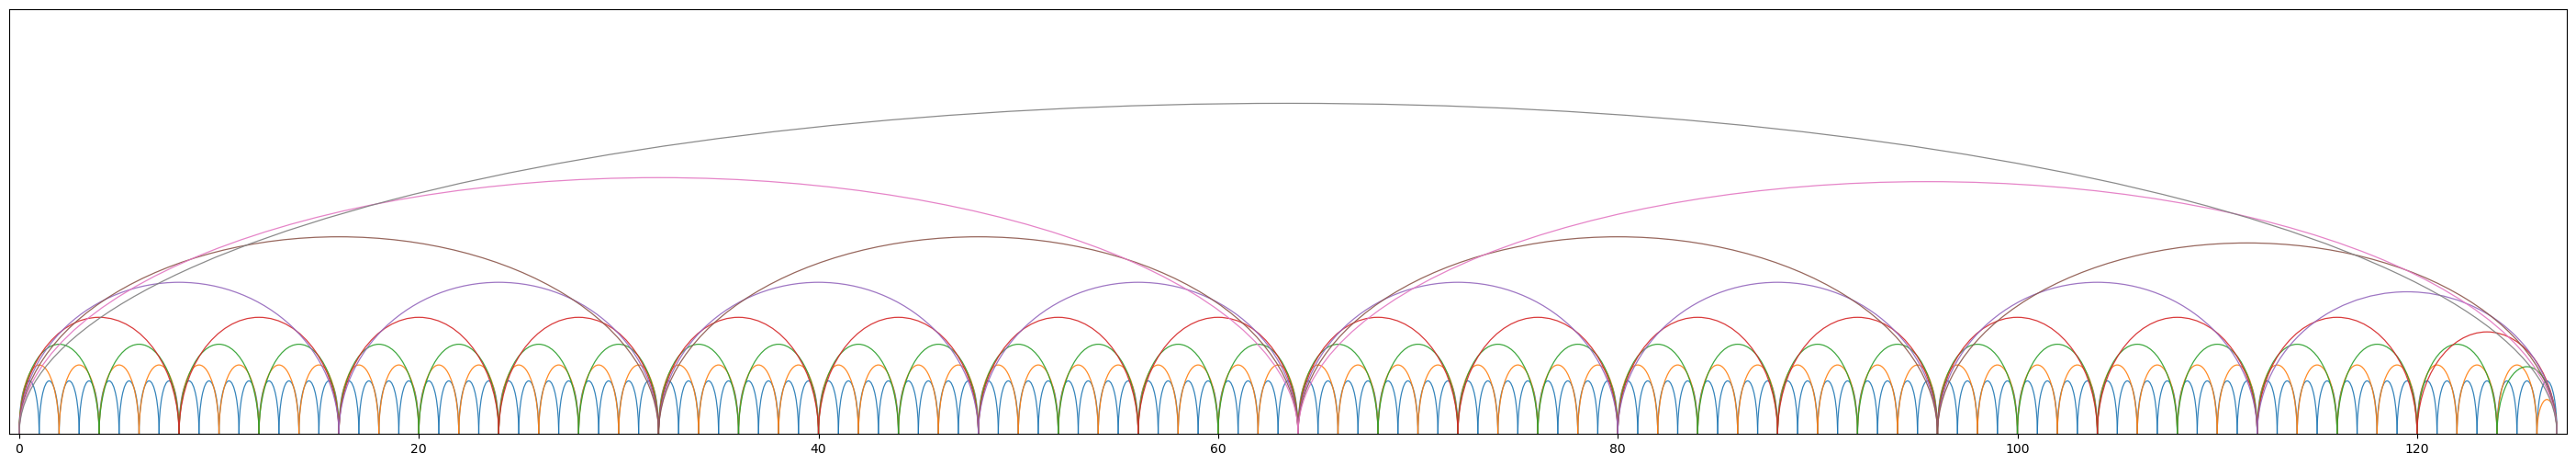

In [80]:
ax = draw_hierarchical_arches(n_ticks=128, base_height=0.25, height_growth=0.65,
                              arc_kwargs={"edgecolor":"C1","linewidth":0.9,"alpha":0.9})

## Apply Same Fourier Implementation to Operator and Back Projection

In [13]:
sys.path.append("../../resample")
from ldm_inverse.measurements import get_noise, get_operator

In [14]:
import torch.nn.functional as F
import torch.fft as fft
def gaussian_kernel(kernel_size=61, sigma=3.0, channels=3, device='cuda'):
    """
    Create a 2D Gaussian kernel for convolution
    """
    ax = torch.arange(-kernel_size // 2 + 1., kernel_size // 2 + 1., device=device)
    xx, yy = torch.meshgrid(ax, ax, indexing='ij')
    kernel = torch.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel = kernel / kernel.sum()
    kernel = kernel.view(1, 1, kernel_size, kernel_size)
    kernel = kernel.repeat(channels, 1, 1, 1)  # multi-channel
    return kernel

    
import torch
import torch.nn.functional as F
import torch.fft as fft


def pad_and_shift_kernel(kernel, H, W):
    """
    Pads kernel to (H, W) centered, then ifftshifts it so that FFT interprets
    the kernel's center at the origin (0,0). This prevents circular shifts.
    """
    kh, kw = kernel.shape[-2:]

    pad_h = H - kh
    pad_w = W - kw

    # Centered padding
    pad_top = pad_h // 2
    pad_bottom = pad_h - pad_top
    pad_left = pad_w // 2
    pad_right = pad_w - pad_left

    kernel_padded = F.pad(kernel, (pad_left, pad_right, pad_top, pad_bottom))

    # Move kernel center to (0,0) for FFT convolution
    kernel_shifted = fft.ifftshift(kernel_padded, dim=(-2, -1))

    return kernel_shifted


def solve_bp_fft_operator(y, x0, kernel, rho=1.0, eps=1e-12):
    """
    Solves: x = (A^T A + rho I)^-1 (A^T y + rho x0)
    where A is convolution with kernel k.

    All FFT operations are done with correct kernel centering to avoid shifts.
    """

    B, C, H, W = y.shape

    # Pad+shift kernel correctly for FFT convolution
    kernel = kernel.reshape(C, 1, *kernel.shape[-2:])  # allow per-channel
    kernel_padded = pad_and_shift_kernel(kernel, H, W)  # shape: (C,1,H,W)

    # If C channels but kernel has 1, broadcast
    if kernel_padded.shape[0] == 1 and C > 1:
        kernel_padded = kernel_padded.repeat(C, 1, 1, 1)

    # Compute FFT of kernel (adjoint via conj)
    k_f = fft.rfft2(kernel_padded.reshape(C, H, W))   # (C, H, W/2+1)

    # Expand kernel to batch dimension
    k_f = k_f.unsqueeze(0).repeat(B, 1, 1, 1)         # (B,C,H,W/2+1)
    k_f = k_f.reshape(B * C, H, W // 2 + 1)

    # FFT of inputs
    y_f  = fft.rfft2(y.reshape(B * C, H, W))
    x0_f = fft.rfft2(x0.reshape(B * C, H, W))

    # Numerator: K* ⊙ Y + rho X0
    numerator = torch.conj(k_f) * y_f + rho * x0_f

    # Denominator: |K|^2 + rho
    denominator = (k_f.abs() ** 2) + rho + eps

    # Solve per-frequency
    x_f = numerator / denominator

    # Back to spatial domain
    x = fft.irfft2(x_f, s=(H, W))
    x = x.reshape(B, C, H, W)

    return x

def solve_bp_fft_operator2(y, x0, kernel, rho=1.0, eps=1e-12):
    """
    Solves: x = (A^T A + rho I)^-1 (A^T y + rho x0)
    where A is convolution with kernel k.

    All FFT operations are done with correct kernel centering to avoid shifts.
    """

    B, C, H, W = y.shape

    # Prepare kernel
    if kernel.ndim == 2:  # (kh, kw)
        kernel = kernel.unsqueeze(0)  # -> (1, kh, kw)
    
    # Pad and shift kernel for FFT convolution
    kernel_reshaped = kernel.reshape(kernel.shape[0], 1, *kernel.shape[-2:])
    kernel_padded = pad_and_shift_kernel(kernel_reshaped, H, W)
    
    # Broadcast kernel if needed
    if kernel_padded.shape[0] == 1 and C > 1:
        kernel_padded = kernel_padded.repeat(C, 1, 1, 1)

    # Compute FFT of kernel (adjoint via conj)
    k_f = fft.rfft2(kernel_padded.reshape(C, H, W))   # (C, H, W/2+1)

    # Expand kernel to batch dimension
    k_f = k_f.unsqueeze(0).repeat(B, 1, 1, 1)         # (B,C,H,W/2+1)
    k_f = k_f.reshape(B * C, H, W // 2 + 1)

    # FFT of inputs
    y_f  = fft.rfft2(y.reshape(B * C, H, W))
    x0_f = fft.rfft2(x0.reshape(B * C, H, W))

    # Numerator: K* ⊙ Y + rho X0
    numerator = torch.conj(k_f) * y_f + rho * x0_f

    # Denominator: |K|^2 + rho
    denominator = (k_f.abs() ** 2) + rho + eps

    # Solve per-frequency
    x_f = numerator / denominator

    # Back to spatial domain
    x = fft.irfft2(x_f, s=(H, W))
    x = x.reshape(B, C, H, W)

    return x

def apply_convolution_operator(image, kernel):
    """
    Apply convolution operator A to an image using FFT: y = A * x
    
    Parameters:
    -----------
    image : torch.Tensor
        Input image of shape (B, C, H, W) or (C, H, W) or (H, W)
    kernel : torch.Tensor
        Convolution kernel of shape (kh, kw) or (C, kh, kw)
        
    Returns:
    --------
    torch.Tensor
        Convolved image, same shape as input
    """
    # Handle different input shapes
    original_shape = image.shape
    
    if image.ndim == 2:  # (H, W)
        image = image.unsqueeze(0).unsqueeze(0)  # -> (1, 1, H, W)
    elif image.ndim == 3:  # (C, H, W)
        image = image.unsqueeze(0)  # -> (1, C, H, W)
    
    B, C, H, W = image.shape
    
    # Prepare kernel
    if kernel.ndim == 2:  # (kh, kw)
        kernel = kernel.unsqueeze(0)  # -> (1, kh, kw)
    
    # Pad and shift kernel for FFT convolution
    kernel_reshaped = kernel.reshape(kernel.shape[0], 1, *kernel.shape[-2:])
    kernel_padded = pad_and_shift_kernel(kernel_reshaped, H, W)
    
    # Broadcast kernel if needed
    if kernel_padded.shape[0] == 1 and C > 1:
        kernel_padded = kernel_padded.repeat(C, 1, 1, 1)
    
    # Compute FFT of kernel
    k_f = fft.rfft2(kernel_padded.reshape(C, H, W))
    
    # Expand to batch dimension
    k_f = k_f.unsqueeze(0).repeat(B, 1, 1, 1)  # (B, C, H, W/2+1)
    k_f = k_f.reshape(B * C, H, W // 2 + 1)
    
    # FFT of image
    x_f = fft.rfft2(image.reshape(B * C, H, W))
    
    # Apply convolution in frequency domain
    y_f = k_f * x_f
    
    # Back to spatial domain
    y = fft.irfft2(y_f, s=(H, W))
    y = y.reshape(B, C, H, W)
    
    # Restore original shape
    if len(original_shape) == 2:
        y = y.squeeze(0).squeeze(0)
    elif len(original_shape) == 3:
        y = y.squeeze(0)
    
    return y



import torch
from PIL import Image
import torchvision.transforms as transforms
import numpy as np


def read_image_to_tensor(image_path, normalize=True, device='cpu'):
    """
    Read an image file and convert it to a PyTorch tensor.
    
    Args:
        image_path (str): Path to the image file
        normalize (bool): If True, normalize pixel values to [0, 1]. Default: True
        device (str): Device to place the tensor on ('cpu' or 'cuda'). Default: 'cpu'
    
    Returns:
        torch.Tensor: Image tensor of shape (C, H, W) with values in [0, 1] if normalized,
                     or [0, 255] if not normalized
    
    Example:
        >>> img_tensor = read_image_to_tensor('path/to/image.jpg')
        >>> print(img_tensor.shape)  # (3, H, W)
    """
    # Read image using PIL
    image = Image.open(image_path).convert('RGB')
    
    # Convert to tensor
    if normalize:
        # Normalize to [0, 1]
        transform = transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
        img_tensor = transform(image)
    else:
        # Keep as [0, 255]
        img_array = np.array(image)
        img_tensor = torch.from_numpy(img_array).permute(2, 0, 1).float()
    
    # Move to specified device
    img_tensor = img_tensor.to(device)
    
    return img_tensor[None, ...]

def to_numpy(t):
    if t.shape[0] == 1:
        t = t[0]
    if len(t.shape) == 3:
        t = t.permute(1, 2, 0)
    else:
        t = t.permute(0, 2, 3, 1)
    n = torch.clamp((t * 0.5 + 0.5) * 255, 0, 255)
    n = n.detach().cpu().numpy().astype("uint8")
    return n

In [15]:
measure_config = {"operator" : {"name": "gaussian_blur",
                                    "kernel_size": 61,
                                    "intensity": 3.0},
                      "noise": {"name": "gaussian",
                                "sigma": 0.01}
                     }
device = "cuda:0"
operator = get_operator(device=device, **measure_config['operator'])
kernel = operator.kernel.clone().to("cuda")
noiser = get_noise(**measure_config['noise'])


### Compart Torch Blur + Fourier BP to Fourier Round Trip
Artifacts gone when using the same Fourier implementation to blur the image and to restore it using BP

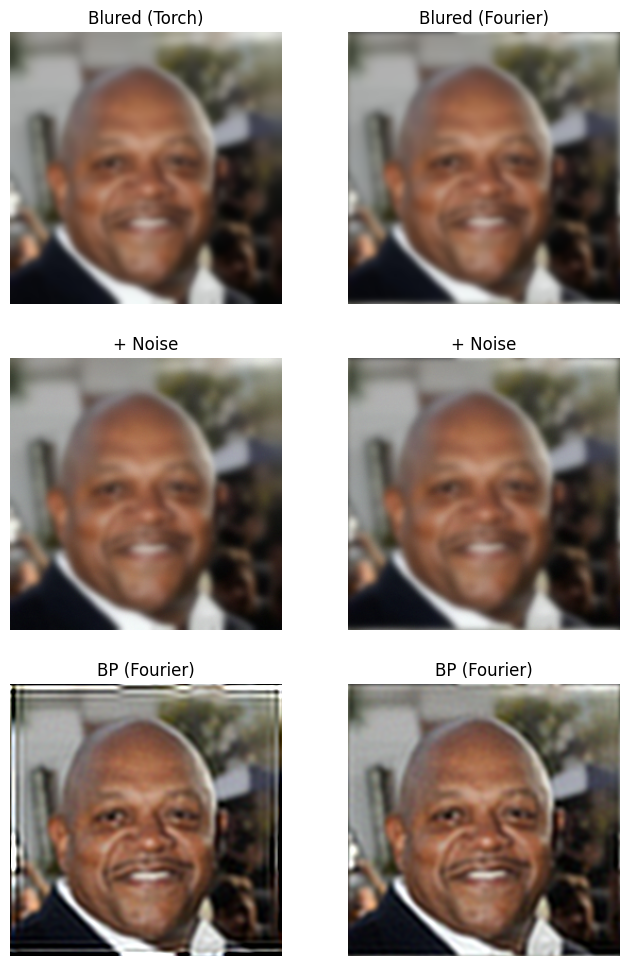

In [16]:
imgp = "../../resample/data/celebs/celebahq_0009.jpg"
img = read_image_to_tensor(imgp, device=device)
# y is using pytorch convolution and yf is using Fourier
y = operator.forward(img)
yf = apply_convolution_operator(img, operator.kernel.to("cuda"))
y_n = noiser(y).to(device)
yf_n = noiser(yf).to(device)

# x_hat and xf_hat are the results of applying BP on y_n and yf_n where BP is implemented with Fourier
x_hat = solve_bp_fft_operator(y_n, y_n*0, gaussian_kernel(), rho=0.005, eps=1e-12)
xf_hat = solve_bp_fft_operator2(yf_n, yf_n*0, operator.kernel.to("cuda"), rho=0.005, eps=1e-12)

fig, ax = plt.subplots(3, 2, figsize=(2*4, 3*4))
mixed_data = [y, y_n, x_hat]
fourier_data = [yf, yf_n, xf_hat]
titles = [("Blured (Torch)", "Blured (Fourier)"),
          ("+ Noise", "+ Noise"),
          ("BP (Fourier)", "BP (Fourier)")]
for axx, m_data, f_data, tit in zip(ax, mixed_data, fourier_data, titles):
    axx[0].imshow(to_numpy(m_data))
    axx[0].set_title(tit[0])
    axx[1].imshow(to_numpy(f_data))
    axx[1].set_title(tit[1])
    for j in range(2):
        axx[j].axis("off")


In [17]:
def encode(img, normalize=True):
    if normalize:
        img = img / 255.0
        img = img - 0.5
    img = img.float()
    return vae.encode(img)

def stochastic_encoding(img, ti, dts, noise=None):
    if noise is None:
        noise = torch.randn_like(img)
    t = ti/dts
    return t*img + (1-t)*noise

    

(1, 249, 249, 3)
(1, 249, 249, 3)
(1, 249, 249, 3)
(1, 249, 249, 3)


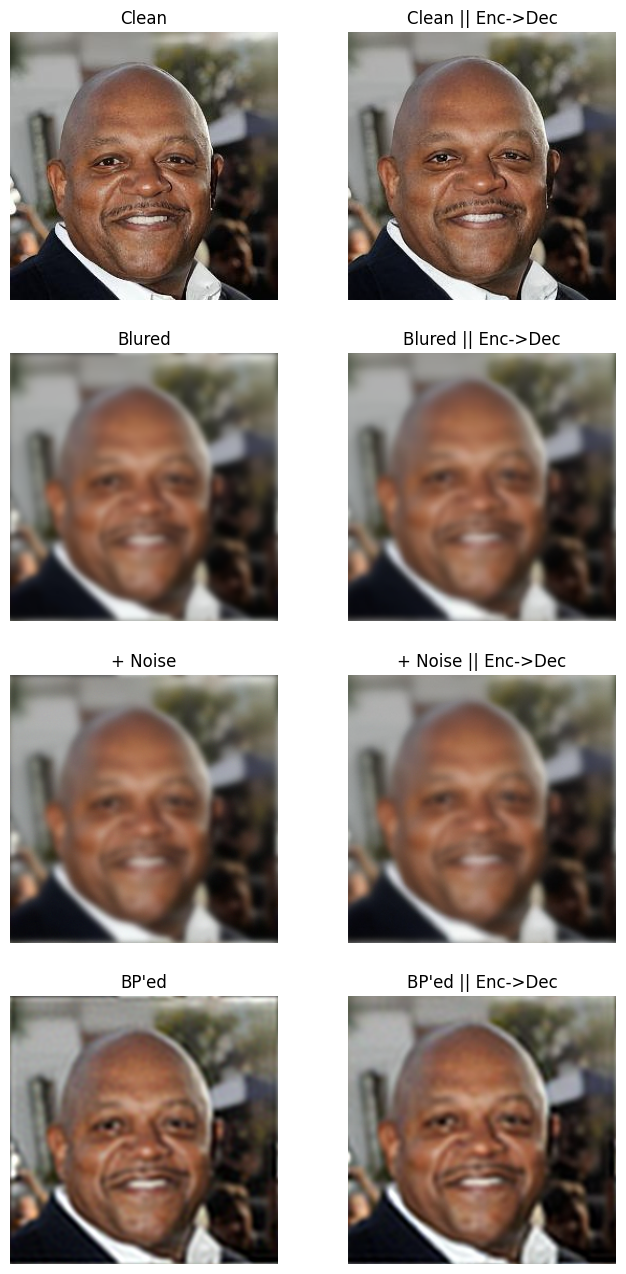

In [19]:
fig, ax = plt.subplots(4, 2, figsize=(2*4, 4*4))
titles = ["Clean", "Blured", "+ Noise", "BP'ed"]
for axx, arr, tit in zip(ax, [img, yf, yf_n, xf_hat], titles):
    latent = encode(arr, False)
    restored = decode(latent)
    print(restored.shape)
    axx[0].imshow(to_numpy(arr))
    axx[1].imshow(restored[0])
    axx[0].set_title(tit)
    axx[1].set_title(tit + " || Enc->Dec")
    for j in range(2):
        axx[j].axis("off")

In [30]:
import sys
sys.path.append("..")
import jax

import jax.numpy as jnp
import numpy as np
from utils.stable_vae import StableVAE


def load_vae_encoder():
    """
    Load and initialize the VAE encoder from StableVAE.
    
    Returns:
    --------
    tuple: (vae, encode_fn, decode_fn, vae_rng)
        - vae: StableVAE instance
        - encode_fn: JIT-compiled encode function
        - decode_fn: JIT-compiled decode function
        - vae_rng: JAX random key for VAE operations
    """
    jax.config.update("jax_enable_x64", False)
    vae = StableVAE.create()
    encode_fn = jax.jit(vae.encode)
    decode_fn = jax.jit(vae.decode)
    vae_rng = jax.random.PRNGKey(42)
    
    print("VAE encoder and decoder initialized")
    return vae, encode_fn, decode_fn, vae_rng


def apply_vae_roundtrip(image, encode_fn, decode_fn, vae_rng):
    """
    Apply VAE encoding followed by decoding to an image.
    
    Parameters:
    -----------
    image : np.ndarray or jnp.ndarray or torch.Tensor
        Input image of shape (H, W, C) or (B, H, W, C)
        Expected value range: [-1, 1] or [0, 1]
    encode_fn : callable
        JIT-compiled VAE encode function
    decode_fn : callable
        JIT-compiled VAE decode function
        
    Returns:
    --------
    np.ndarray
        Reconstructed image with same shape as input
    """
    # Convert to numpy if torch tensor
    if hasattr(image, 'detach'):
        image = image.detach().cpu().numpy()
    
    # Ensure numpy array
    image = np.asarray(image)
    
#     # Normalize to [-1, 1] if in [0, 1]
#     if image.max() > 1.0:
#         image = image / 255.0
#     if image.min() >= 0 and image.max() <= 1.0:
#         image = image * 2.0 - 1.0
    
    # Add batch dimension if needed
    original_shape = image.shape
    if image.ndim == 3:
        image = image[np.newaxis, ...]  # (H, W, C) -> (1, H, W, C)
    
    # Ensure channel-last format (B, H, W, C)
    if image.shape[-1] != 3:
        if image.shape[1] == 3:  # (B, C, H, W) -> (B, H, W, C)
            image = np.transpose(image, (0, 2, 3, 1))
    
    # Convert to JAX array
    image_jax = jnp.array(image)
    
    # Encode to latent space
    latent = encode_fn(vae_rng, image_jax)
    
    # Decode back to image space
    reconstructed_jax = decode_fn(latent)
    
    # Convert back to numpy
    reconstructed = np.array(reconstructed_jax)
    
    # Remove batch dimension if it was added
    if len(original_shape) == 3:
        reconstructed = reconstructed[0]
    
    return reconstructed

_, encode_fn, decode_fn, vae_rng = load_vae_encoder()

/home/nec/miniconda3/envs/shortcut-gpu-both/lib/python3.10/site-packages/diffusers/configuration_utils.py:239: FutureWarning: It is deprecated to pass a pretrained model name or path to `from_config`.
  deprecate("config-passed-as-path", "1.0.0", deprecation_message, standard_warn=False)


VAE encoder and decoder initialized


1.1138936
0.971696
0.94876456
1.0413154


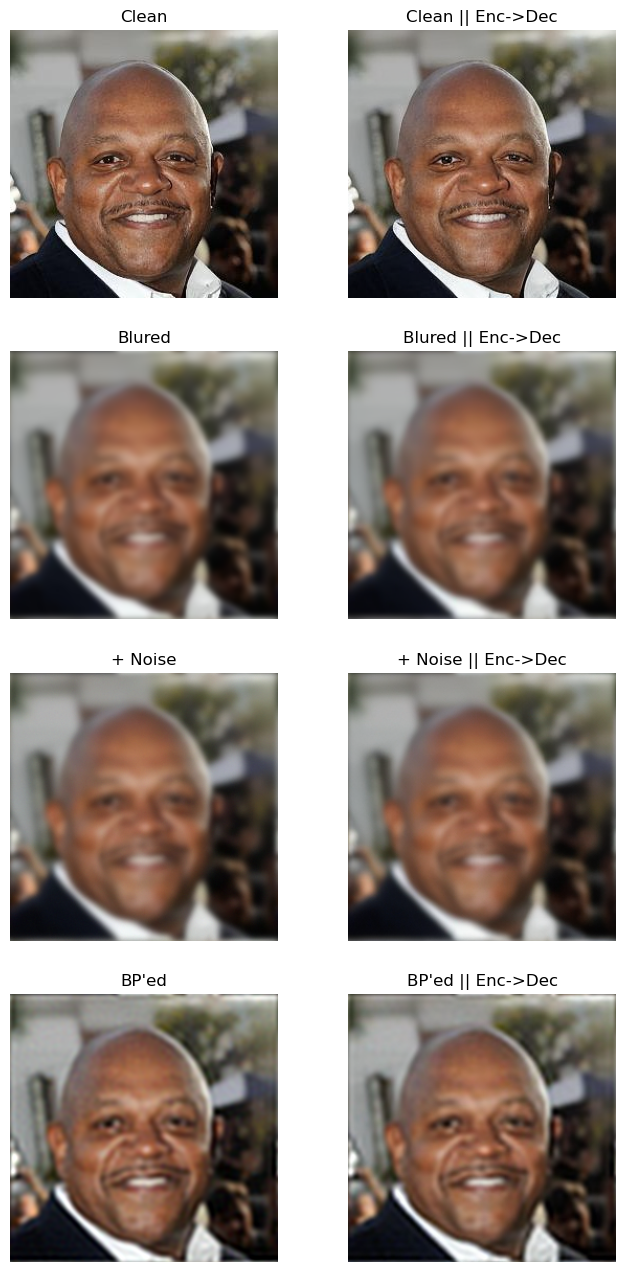

In [31]:
fig, ax = plt.subplots(4, 2, figsize=(2*4, 4*4))
titles = ["Clean", "Blured", "+ Noise", "BP'ed"]
for axx, arr, tit in zip(ax, [img, yf, yf_n, xf_hat], titles):
    restored = apply_vae_roundtrip(arr, encode_fn, decode_fn, vae_rng)
    axx[0].imshow(to_numpy(arr[0]))
    axx[1].imshow(rescale_img(restored[0]))
    axx[0].set_title(tit)
    axx[1].set_title(tit + " || Enc->Dec")
    for j in range(2):
        axx[j].axis("off")

In [32]:
bb_latent = encode(xf_hat, False)


TypeError: dtype torch.float32 not understood

In [69]:
dts =64
ti=61
st_encoded = stochastic_encoding(bb_latent, ti, dts)
labels = torch.randint(0, num_classes, (bb_latent.shape[0],), device=device)
res = [st_encoded]
for i in range(ti, dts):
    step_out = step(res[-1], i, dts, labels)
    print(step_out.min(), step_out.max())
    res.append(step_out)

    


tensor(-5.5023, device='cuda:0', grad_fn=<MinBackward1>) tensor(7.0693, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(-5.5723, device='cuda:0', grad_fn=<MinBackward1>) tensor(7.1628, device='cuda:0', grad_fn=<MaxBackward1>)
tensor(-5.6409, device='cuda:0', grad_fn=<MinBackward1>) tensor(7.2551, device='cuda:0', grad_fn=<MaxBackward1>)


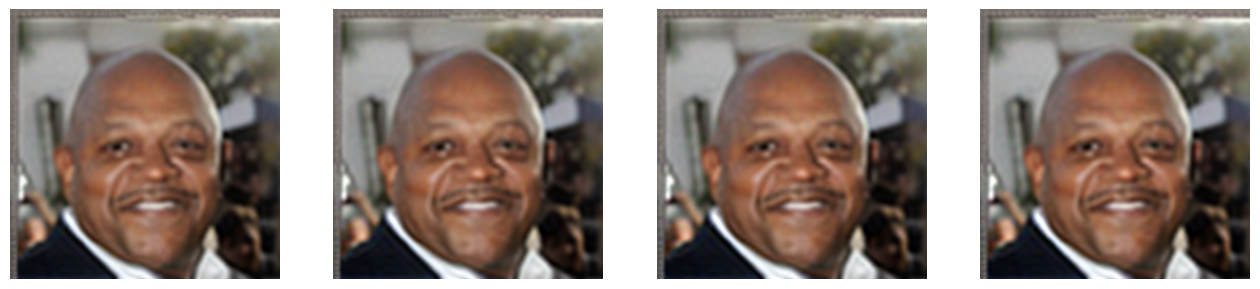

In [70]:
fig, ax = plt.subplots(1, len(res), figsize=(4*len(res), 4))
for idx, r in enumerate(res):
    dec_r = decode(r)
    ax[idx].imshow(dec_r[0])
    ax[idx].axis("off")
    

# With data fidelity step

In [63]:
labels = torch.randint(0, num_classes, (bb_latent.shape[0],), device=device)

dts=64
ti=58

y_n_norm = yf_n / 255.5 - 0.5

z_t = stochastic_encoding(bb_latent, ti, dts)
zs = [to_numpy(decode(z_t, False))]
xp = []
xd =[]
for i in range(ti, dts):
    z_prev = step(z_t, i, dts, labels)
#     print(z_prev.min(), z_prev.max())
    x_prev = decode(z_prev, False)
    xp.append(to_numpy(x_prev))
#     print(x_prev.min(), x_prev.max())
#     print(y_n.max(), torch.tensor(x_prev).to(device).permute(0, 3, 1, 2).max())
    x_data = solve_bp_fft_operator2(y_n, x_prev, kernel, rho=0.1, eps=1e-12)
#     print(x_data.min(), x_data.max())
    xd.append(to_numpy(x_data))
    z_data = encode(x_data, False)
#     print(z_data.min(), z_data.max())
    z_t = stochastic_encoding(z_data, dts-1, dts)
#     print(z_t.min(), z_t.max())
    zs.append(to_numpy(decode(z_t, False)))
#     print("====================")


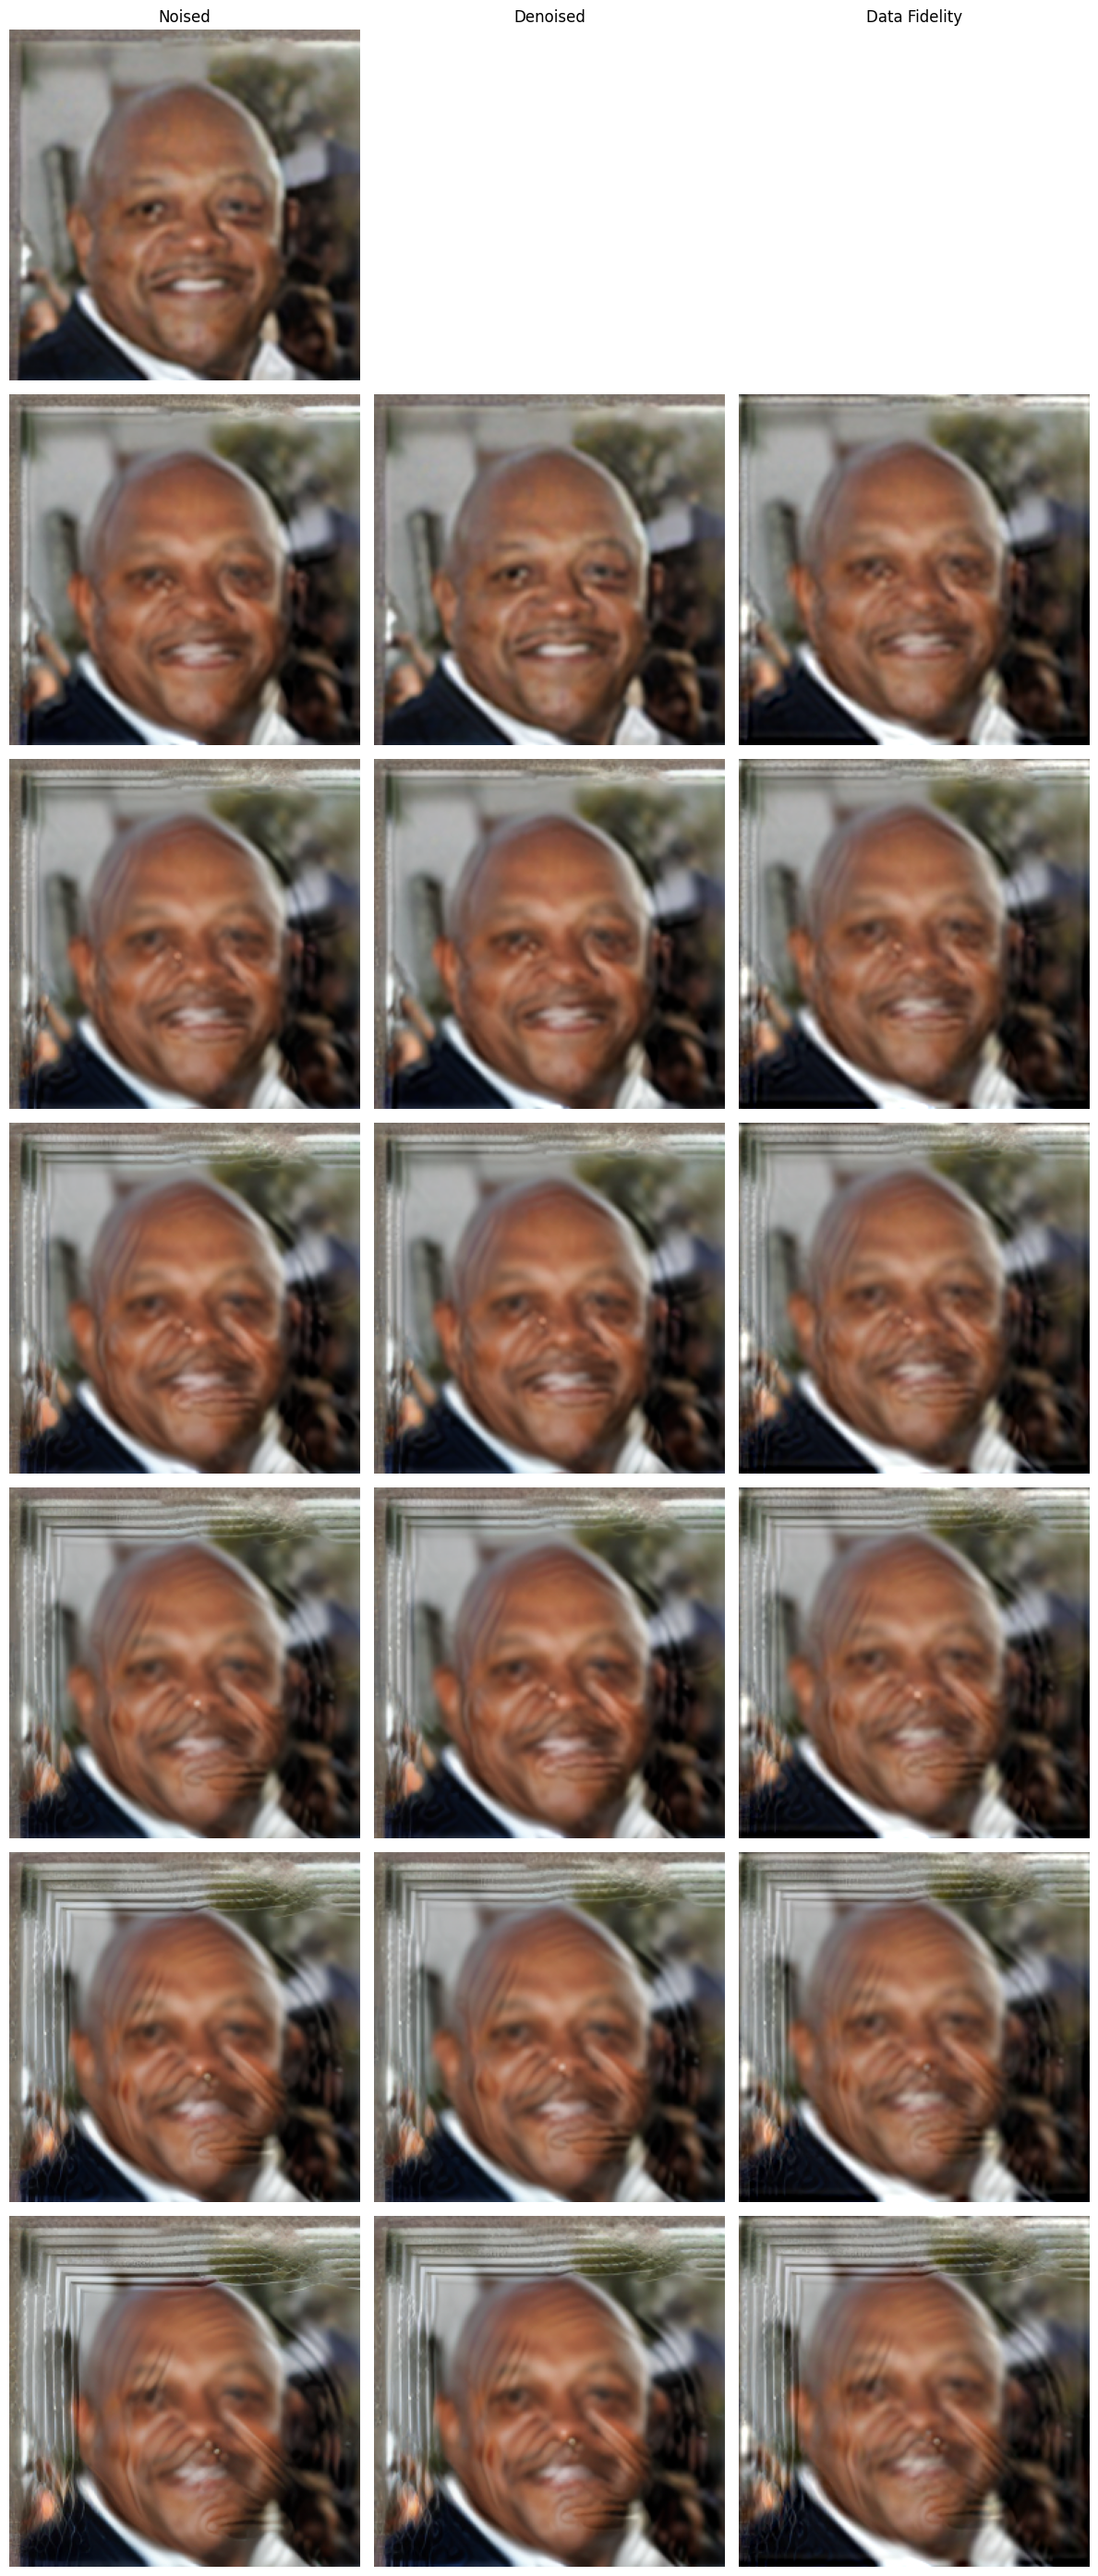

In [64]:
def display_triplet_grid(zs, xp, xd, t: float,
                         figsize = None,
                         cmap = None,
                         save_path = None):
    """
    Display images in a grid with 3 columns and len(zs) rows.

    Layout:
    - rows = len(zs)
    - columns = ["Noised", "Denoised", "Data Fidelity"]
    - row 0: left column shows zs[0], middle/right are empty
    - row r (>=1): left=zs[r], middle=xp[r-1], right=xd[r-1]

    Row labels:
    - row 0 label: `t={t}`
    - row r (>=1) label: `t={t}+{k}/{t+len(xp)}` where k = r-1

    Parameters:
    - zs, xp, xd: sequences of images (numpy arrays, torch tensors, or PIL-like)
      with len(zs) == len(xp) + 1 == len(xd) + 1
    - t: numeric parameter used in row labels
    - figsize: optional matplotlib figsize
    - cmap: colormap for single-channel images
    - save_path: optional path to save the figure
    """
    if not (len(zs) == len(xp) + 1 == len(xd) + 1):
        raise ValueError("Expected len(zs) == len(xp) + 1 == len(xd) + 1")

    nrows = len(zs)
    ncols = 3

    if figsize is None:
        figsize = (4 * ncols, max(2, nrows)*4)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)

    # Normalize axes shape (when nrows == 1 matplotlib returns 1D axes)
    if nrows == 1:
        axes = np.expand_dims(axes, 0)

    col_titles = ["Noised", "Denoised", "Data Fidelity"]
    for c, title in enumerate(col_titles):
        axes[0, c].set_title(title)

    for r in range(nrows):
        # Left column: always zs[r]
        ax_left = axes[r, 0]
        img_z = zs[r]
        ax_left.imshow(img_z)
        ax_left.axis('off')

        # Label for the row
        if r == 0:
            label = f"t={t}"
        else:
            k = r - 1
            denom = t + len(xp)
            label = f"t={t}+{k}/{denom}"
        ax_left.set_ylabel(label, rotation=0, labelpad=40, va='center')

        if r == 0:
            # middle and right empty
            axes[r, 1].axis('off')
            axes[r, 2].axis('off')
        else:
            ax_mid = axes[r, 1]
            ax_right = axes[r, 2]

            img_p = xp[r - 1]
            img_d = xd[r - 1]


            ax_mid.imshow(img_p)
            ax_mid.axis('off')

            ax_right.imshow(img_d)
            ax_right.axis('off')

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    
display_triplet_grid(zs, xp, xd, ti)

In [220]:
from typing import List, Tuple, Iterable, Optional
from collections import deque
from fractions import Fraction

def shortest_aligned_plan_to_end(current_index: int,
                                 current_total: int,
                                 allowed_totals: Optional[Iterable[int]] = None
                                ) -> Tuple[List[int], List[int]]:
    """
    Compute minimal sequence of aligned steps to reach p == 1 starting from
    p = current_index / current_total under the rule:
      - step(k, T) is allowed only when p == k / T (i.e. p * T is integer)
      - calling step(k, T) moves p -> (k + 1) / T

    Args:
      current_index: int, 0 <= current_index < current_total
      current_total: int, dyadic total (power of two) that current_index refers to
      allowed_totals: iterable of allowed totals (default: [2,4,8,16,32,64,128])

    Returns:
      (indices, totals): two parallel lists describing the calls in order.
    """
    if allowed_totals is None:
        allowed_totals = [2, 4, 8, 16, 32, 64, 128]
    allowed = sorted(set(allowed_totals))

    if current_total not in allowed:
        raise ValueError("current_total must be one of allowed_totals")

    if current_total < 2 or (current_total & (current_total - 1)) != 0:
        raise ValueError("current_total must be a power of two >= 2")
    if not (0 <= current_index < current_total):
        raise ValueError("current_index must be in [0, current_total-1]")

    start_p = Fraction(current_index, current_total)
    target = Fraction(1, 1)

    # Quick exit if somehow already at or beyond end
    if start_p >= target:
        return [], []

    # BFS over reachable p values (rationals of form (k+1)/T)
    q = deque([start_p])
    prev = {start_p: (None, None)}  # map p -> (prev_p, (idx, T))
    visited = {start_p}

    while q:
        p = q.popleft()
        # for each allowed grid T, only allow a step if p * T is integer
        for T in allowed:
            # check alignment: p * T must be integer
            if (p.numerator * T) % p.denominator != 0:
                continue
            k = (p.numerator * T) // p.denominator  # exact integer
            # k must be in [0, T-1] since p < 1
            if not (0 <= k < T):
                continue
            p_next = Fraction(k + 1, T)  # result of step(k,T)
            # only forward progress (should always be > p though)
            if p_next <= p:
                continue
            if p_next in visited:
                continue
            prev[p_next] = (p, (k, T))
            if p_next == target:
                # reconstruct path
                inds: List[int] = []
                tots: List[int] = []
                cur = p_next
                while True:
                    pprev, action = prev[cur]
                    if pprev is None:
                        break
                    k_act, T_act = action
                    inds.append(k_act)
                    tots.append(T_act)
                    cur = pprev
                inds.reverse()
                tots.reverse()
                return inds, tots
            visited.add(p_next)
            q.append(p_next)

    # If we cannot reach p == 1 with these allowed totals, raise.
    raise RuntimeError("Unable to reach end with the given allowed_totals")

shortest_aligned_plan_to_end()

TypeError: shortest_aligned_plan_to_end() missing 2 required positional arguments: 'current_index' and 'current_total'

In [54]:
import os.path as osp
from glob import glob
benchmark_dir = "../../resample/results/baseline64/recon"
test_dir = "../results/tests/64_steps_gamma1_mod10/recon"
benchmarl_imgs = glob(osp.join(benchmark_dir, "*.png"))
test_imgs = glob(osp.join(test_dir, "*.png"))
orig_imgs = glob(osp.join(test_dir.replace("recon", "input"), "*.png"))

images = []
for imgp1, imgp2, imgp3 in zip(orig_imgs, benchmarl_imgs, test_imgs):
    images.append(plt.imread(imgp1))
    images.append(plt.imread(imgp2))
    images.append(plt.imread(imgp3))
all_images = np.stack(images)[..., :-1]
n = 20
indices = np.random.permutation(64)[:n]*3
indices_l = []
for i in indices:
    indices_l.append(i)
    indices_l.append(i+1)
    indices_l.append(i+2)
print(indices_l)
fig, ax = show_image_grid(all_images[indices_l], 3, figsize=(4*3, 4*n))

# images = [plt.imread("../results/integration/gamma_1/input/000_true.png"),
#         plt.imread("../results/integration/64_gamma_1/input/001_true.png"),
#     plt.imread("../results/integration/64_gamma_1/recon/000_recon.png"),
# plt.imread("../results/integration/gamma_1/recon/001_recon.png"),
# plt.imread("../../resample/results/benchmarkx2/recon/000_recon.png"),
# plt.imread("../../resample/results/benchmarkx2/recon/001_recon.png")]

# all_images = np.stack(images)[..., :-1]
# fig, ax = show_image_grid(all_images, 2)

[174, 175, 176, 45, 46, 47, 27, 28, 29, 186, 187, 188, 144, 145, 146, 153, 154, 155, 72, 73, 74, 177, 178, 179, 6, 7, 8, 108, 109, 110, 135, 136, 137, 93, 94, 95, 87, 88, 89, 0, 1, 2, 69, 70, 71, 123, 124, 125, 96, 97, 98, 105, 106, 107, 189, 190, 191, 18, 19, 20]


NameError: name 'show_image_grid' is not defined